In [1]:
import sys
sys.path.insert(0, '/Users/lyuan13/Downloads/pca_sphere_projection/')
import pca_sphere_projection.core as pc

import pandas as pd
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import numpy as np
import seaborn as sns
from scipy.spatial.transform import Rotation as R
from matplotlib.colors import ListedColormap
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
from scipy.stats import pearsonr
import matplotlib.cm as cm
import statsmodels.stats.multitest as smm

In [2]:
def cartesian_to_spherical(x, y, z):
    longitude = np.arctan2(y, x)
    latitude = np.arcsin(z / np.sqrt(x**2 + y**2 + z**2))
    return longitude, latitude

In [3]:
data = pd.read_csv('uc_epi_pca.csv')
groups = data.groupby('celltype')
centroids = data.groupby('celltype')[['PC1', 'PC2', 'PC3']].mean()

trajectory1 = ['Stem', 'Secretory TA', 'Immature Goblet', 'Goblet']
trajectory2 = ['Stem', 'TA 2', 'Immature Enterocytes 2', 'Enterocytes']

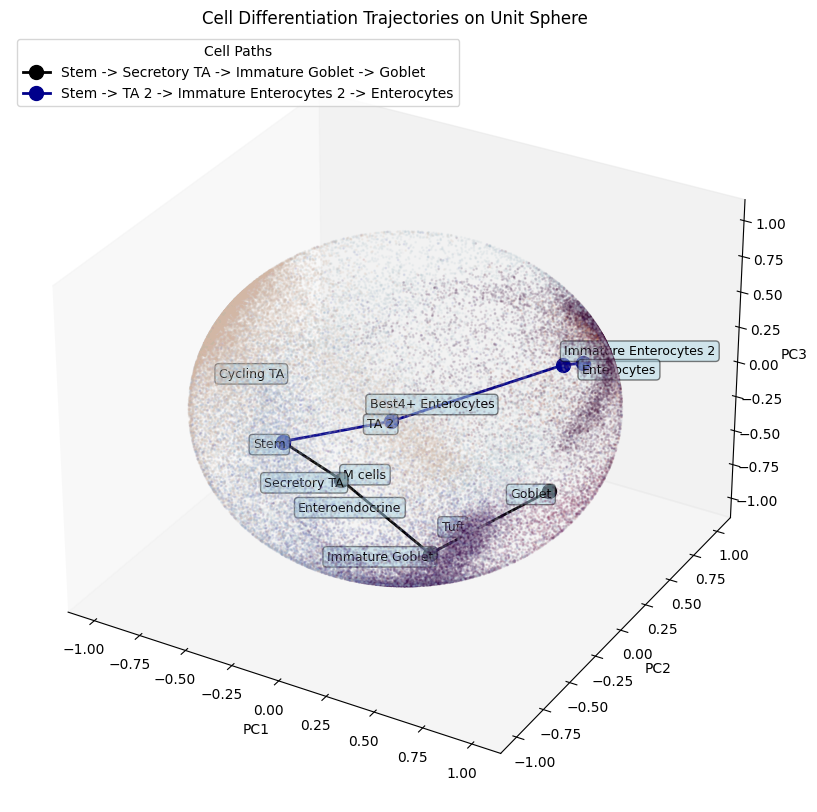

In [4]:
celltypes = data['celltype'].astype('category').cat.codes
unique_celltypes = data['celltype'].unique() 
colormap = cm.get_cmap('twilight_r', len(unique_celltypes))

fig = plt.figure(figsize=(10, 10))
ax = fig.add_subplot(111, projection='3d')

texts = []
annotated = set() 
for name, group in groups:
    color_index = data['celltype'].astype('category').cat.categories.get_loc(name)
    color = colormap(color_index / len(unique_celltypes))
    centroid = group[['PC1', 'PC2', 'PC3']].mean()
    ax.scatter(group['PC1'], group['PC2'], group['PC3'], c=[color],  s=1, alpha=0.1)
    if name not in annotated and name not in ['Enterocytes', 'Immature Enterocytes 2']: 
        offset = (0.01, 0.01, -0.05)  # Standard offset
        text = ax.text(centroid['PC1'] + offset[0], centroid['PC2'] + offset[1], centroid['PC3'] + offset[2],
                       name, fontsize=9, ha='right', bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.5))
        texts.append(text)
        annotated.add(name)  

for trajectory, color in [(trajectory1, 'black'), (trajectory2, 'darkblue')]:
    path_points = centroids.loc[trajectory]
    ax.plot(path_points['PC1'], path_points['PC2'], path_points['PC3'],
            color=color, marker='o', markersize=10, linewidth=2, label=' -> '.join(trajectory))
    for point, label in zip(path_points.values, trajectory):
        #
        if label == 'Immature Enterocytes 2':
            offset = (0.02, -0.03, 0.1)
        elif label == 'Enterocytes':
            offset = (-0.02, 0.03, -0.1)
        else:
            offset = (0.01, 0.01, 0.1)

        
        if label not in annotated: 
            ax.text(point[0] + offset[0], point[1] + offset[1], point[2] + offset[2], label, size=9,
                    bbox=dict(boxstyle="round,pad=0.3", facecolor='lightblue', alpha=0.5))
            annotated.add(label) 
            
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.set_title('Cell Differentiation Trajectories on Unit Sphere')
ax.legend(title='Cell Paths', bbox_to_anchor=(0, 1), loc='upper left')

ax.patch.set_facecolor('none') 
ax.grid(False)
plt.show()

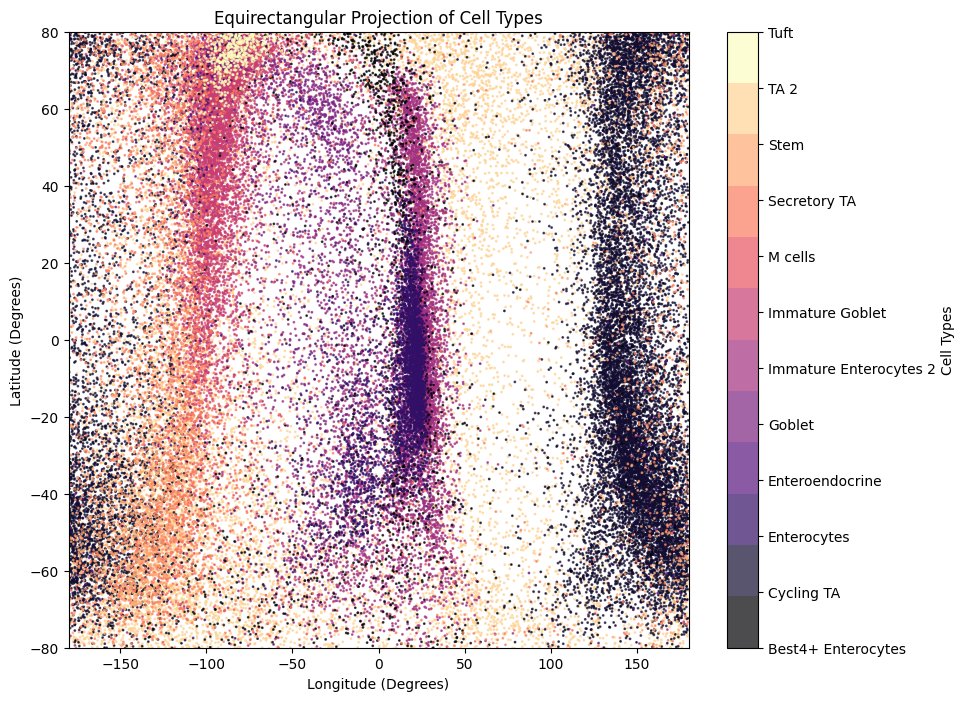

In [5]:
centroid = data[data['celltype'] == 'Stem'][['PC1', 'PC2', 'PC3']].mean().values

data = pc.align_to_north_pole(data, pcs_columns=['PC1', 'PC2', 'PC3'], cluster_column='cluster', root_node=centroid)
data = pc.apply_euler_rotation(data, pcs_columns=['PC1', 'PC2', 'PC3'], rotation_angles=[-90,-50,50], degrees=True)
pc.equirectangular_projection(data, 
                              pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                              cluster_column='celltype', 
                              categories=None, 
                              selected_celltypes=None, 
                              colormap='magma', 
                              figsize=(10, 8), 
                              point_size=1, 
                              alpha=0.7, 
                              xlim=(-180, 180), 
                              ylim=(-80, 80))

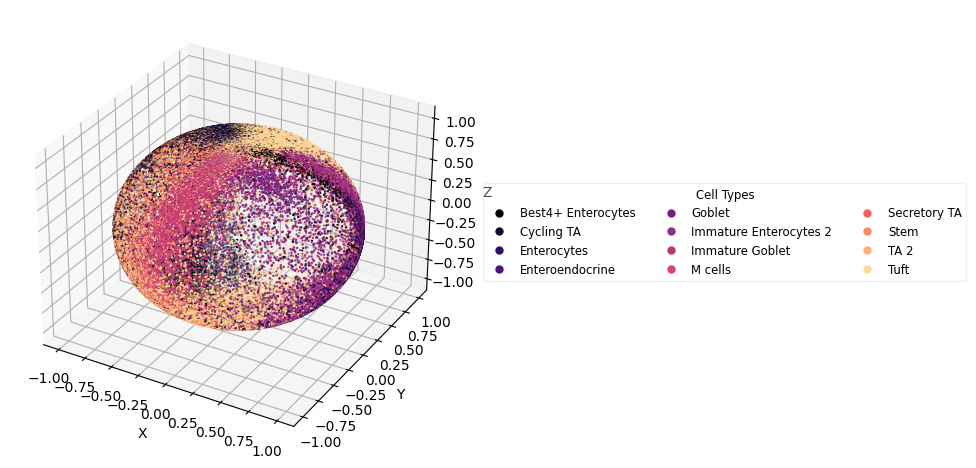

In [6]:
pc.visualize_globe( data, 
                    pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                    cluster_column='celltype', 
                    colormap='magma', 
                    point_size=0.5, 
                    interactive=False, 
                    output_html=None, 
                    figsize=(10, 10), 
                    legend_columns=3)

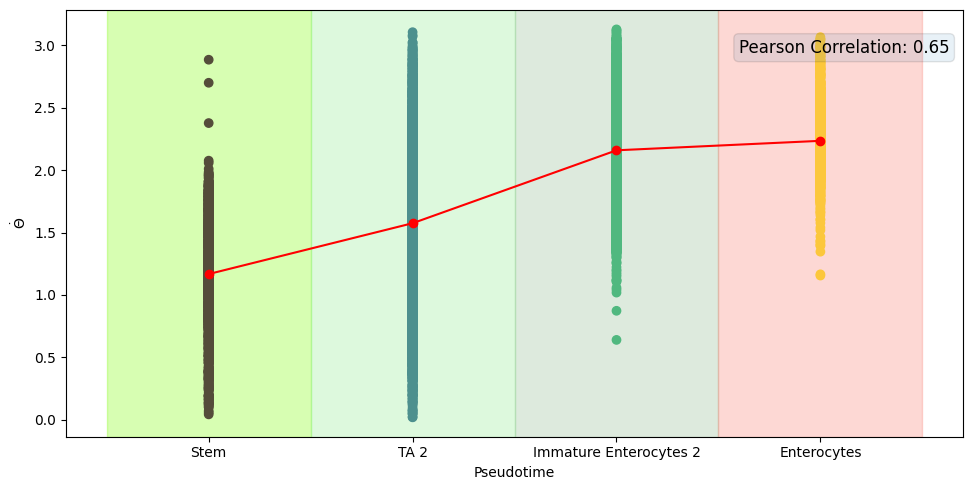

In [10]:
######################################
# Customized plotting for aesthetics #
######################################
data = pd.read_csv('uc_epi_pca.csv')
centroid = data[data['celltype'] == 'Stem'][['PC1', 'PC2', 'PC3']].mean().values
data = pc.align_to_north_pole(data, pcs_columns=['PC1', 'PC2', 'PC3'], cluster_column='cluster', root_node=centroid)
data = pc.apply_euler_rotation(data, pcs_columns=['PC1', 'PC2', 'PC3'], rotation_angles=[0,20,0], degrees=True)

cell_types_of_interest = [
    'Stem', 
    'TA 2', 
    'Immature Enterocytes 2', 
    'Enterocytes'
]
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()

filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)
filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)

stages = {
    'Stem': (0, 2.5),        
    'TA 2': (2.5, 5),   
    'Immature Enterocytes 2': (5, 7.5),         
    'Enterocytes': (7.5, 10)      
}

category_scale = {
    'Stem': 1.25, 
    'TA 2': 3.75,  
    'Immature Enterocytes 2': 6.25, 
    'Enterocytes': 8.75 
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])

fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(cell_types_of_interest)

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lawngreen', 'lightgreen', 'darkseagreen', 'salmon']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

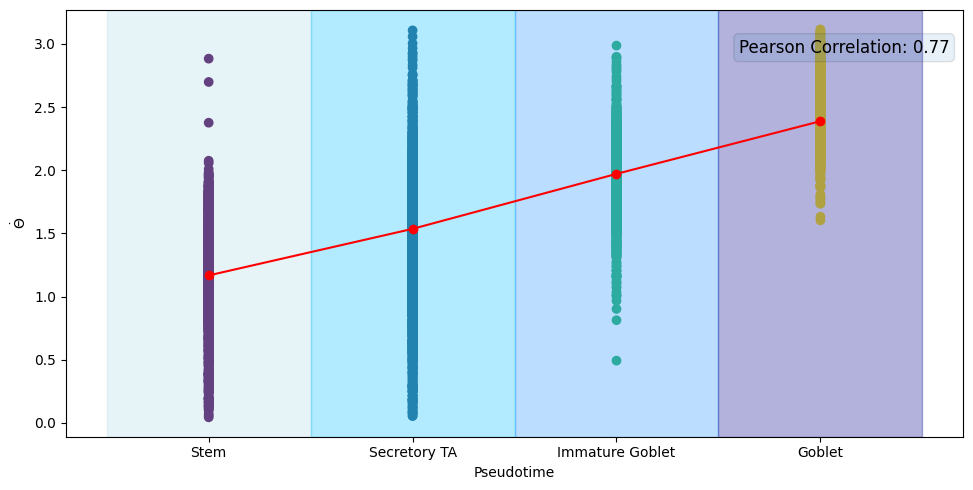

In [11]:
cell_types_of_interest = [
    'Stem', 
    'Secretory TA', 
    'Immature Goblet', 
    'Goblet'
]
filtered_data = data[data['celltype'].isin(cell_types_of_interest)].copy()
filtered_data['celltype'] = pd.Categorical(filtered_data['celltype'], categories=cell_types_of_interest, ordered=True)

filtered_data[['theta', 'phi']] = filtered_data.apply(
    lambda row: pc.calculate_spherical_angles(row['rotated_PC1'], row['rotated_PC2'], row['rotated_PC3']), axis=1, result_type='expand'
)


stages = {
    'Stem': (0, 2.5),          
    'Secretory TA': (2.5, 5),   
    'Immature Goblet': (5, 7.5),          
    'Goblet': (7.5, 10)    
}

category_scale = {
    'Stem': 1.25, 
    'Secretory TA': 3.75, 
    'Immature Goblet': 6.25,  
    'Goblet': 8.75 
}

filtered_data['pseudotime_mapped'] = filtered_data['celltype'].map(category_scale)
correlation, p_value = pearsonr(filtered_data['pseudotime_mapped'], filtered_data['theta'])


fig, ax = plt.subplots(figsize=(10, 5))
scatter = ax.scatter(filtered_data['pseudotime_mapped'], filtered_data['theta'],
                     c=filtered_data['celltype'].cat.codes, cmap='viridis')
ax.set_xticks(list(category_scale.values()))
ax.set_xticklabels(cell_types_of_interest)

medians = filtered_data.groupby('celltype')['theta'].median()
ax.plot([category_scale[cat] for cat in medians.index], medians.values, marker='o', linestyle='-', color='red', label='Median Theta')

colors = ['lightblue', 'deepskyblue', 'dodgerblue', 'darkblue']
for stage, interval in stages.items():
    ax.axvspan(interval[0], interval[1], color=colors.pop(0), alpha=0.3, label=stage)

ax.set_xlabel('Pseudotime')
ax.set_ylabel(r"$\dot{\Theta}$")
plt.annotate(f'Pearson Correlation: {correlation:.2f}', xy=(0.75, 0.90), xycoords='axes fraction', fontsize=12, bbox=dict(boxstyle="round", alpha=0.1))
plt.tight_layout()
plt.show()

C:\Users\lyuan13\.conda\envs\tf\lib\site-packages\scipy\stats\morestats.py:1760: UserWarning: p-value may not be accurate for N > 5000.
  warnings.warn("p-value may not be accurate for N > 5000.")


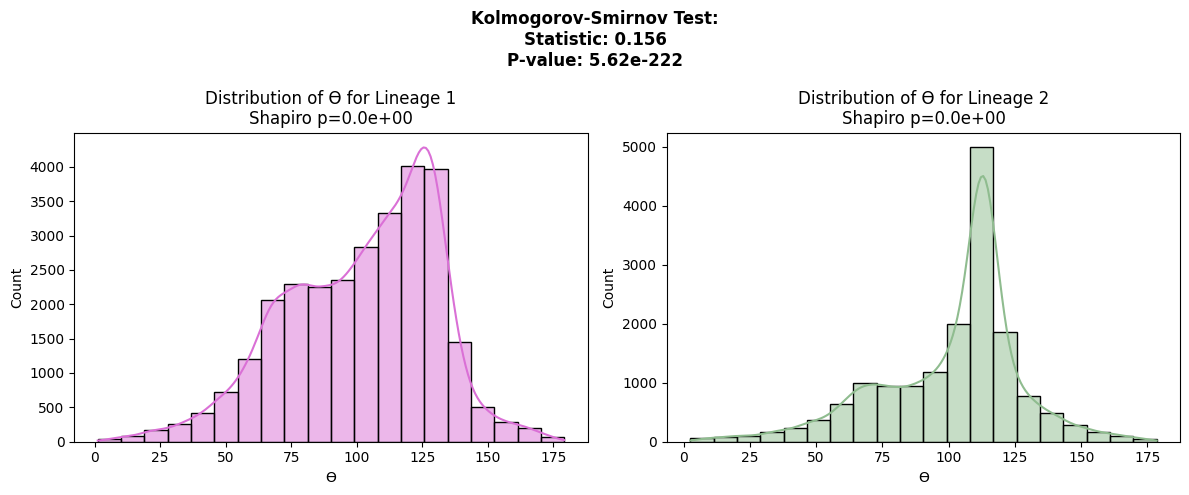

{'test_type': 'Kolmogorov-Smirnov Test',
 'test_statistic': 0.1560385434682946,
 'p_value': 5.61518504269608e-222}

In [12]:
pc.statistical_test_on_lineages(  data, 
                                  lineage1=['Stem', 'TA 2', 'Immature Enterocytes 2', 'Enterocytes'], 
                                  lineage2=['Stem', 'Secretory TA', 'Immature Goblet', 'Goblet'], 
                                  pcs_columns=['rotated_PC1', 'rotated_PC2', 'rotated_PC3'], 
                                  cluster_column='celltype', 
                                  figsize=(12, 5))